In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Linear Regression Implementation from Scratch

We are now ready to work through 
a fully functioning implementation 
of linear regression. 
In this section, 
we will implement the entire method from scratch,
including (i) the model; (ii) the loss function;
(iii) a minibatch stochastic gradient descent optimizer;
and (iv) the training function 
that stitches all of these pieces together.
Finally, we will run our synthetic data generator
from that section
and apply our model
on the resulting dataset. 
While modern deep learning frameworks 
can automate nearly all of this work,
implementing things from scratch is the only way
to make sure that you really know what you are doing.
Moreover, when it is time to customize models,
defining our own layers or loss functions,
understanding how things work under the hood will prove handy.
In this section, we will rely only 
on tensors and automatic differentiation.
Later, we will introduce a more concise implementation,
taking advantage of the bells and whistles of deep learning frameworks 
while retaining the structure of what follows below.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import optax

## Defining the Model

Before we can begin optimizing our model's parameters by minibatch SGD,
we need to have some parameters in the first place.
In the following we initialize weights by drawing
random numbers from a normal distribution with mean 0
and a standard deviation of 0.01. 
The magic number 0.01 often works well in practice, 
but you can specify a different value 
through the argument `sigma`.
Moreover we set the bias to 0.
Note that for object-oriented design
we add the code to the `__init__` method of a subclass of `d2l.Module` (introduced in that section).

In [2]:
class LinearRegressionScratch(d2l.Module):
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr, sigma=0.01, rngs=None):
        super().__init__()
        self.save_hyperparameters(ignore=['rngs'])
        rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
        self.w = nnx.Param(
            rngs.params.normal((num_inputs, 1)) * sigma)
        self.b = nnx.Param(jnp.zeros(1))

Next we must define our model,
relating its input and parameters to its output.
Using the same notation as the equation
for our linear model we simply take the matrix--vector product
of the input features $\mathbf{X}$ 
and the model weights $\mathbf{w}$,
and add the offset $b$ to each example.
The product $\mathbf{Xw}$ is a vector and $b$ is a scalar.
Because of the broadcasting mechanism 
(see that section),
when we add a vector and a scalar,
the scalar is added to each component of the vector.
The resulting `forward` method 
is registered in the `LinearRegressionScratch` class
via `add_to_class` (introduced in that section).

In [3]:
@d2l.add_to_class(LinearRegressionScratch)
def forward(self, X):
    return d2l.matmul(X, self.w) + self.b

## Defining the Loss Function

Since updating our model requires taking
the gradient of our loss function,
we ought to define the loss function first.
Here we use the squared loss function
in the equation.
Our synthetic data loader already yields labels `y`
with the same shape as the predictions `y_hat`
(both are $(B, 1)$ column vectors for a batch of size $B$),
so we can subtract them elementwise directly;
exercise 5 asks what would go wrong
if the two shapes did not match.
We return the averaged loss value
among all examples in the minibatch.

In [4]:
@d2l.add_to_class(LinearRegressionScratch)
def loss(self, y_hat, y):
    l = (y_hat - d2l.reshape(y, y_hat.shape)) ** 2 / 2
    return d2l.reduce_mean(l)

Before handing this loss to an optimizer, compute by hand the
gradient that the optimizer will consume. For a single example, the loss is
$\ell = \frac{1}{2}(\hat{y} - y)^2$ with $\hat{y} = \mathbf{w}^\top \mathbf{x} + b$,
and the chain rule gives

$$\frac{\partial \ell}{\partial \mathbf{w}} = (\hat{y} - y)\, \mathbf{x} \qquad \textrm{and} \qquad \frac{\partial \ell}{\partial b} = \hat{y} - y.$$

Differentiating the square produces the error $\hat{y} - y$, which is then
multiplied by the derivative of $\hat{y}$ with respect to each parameter:
$\mathbf{x}$ for the weights and $1$ for the bias. In words, *the gradient is
the error-weighted input*: each weight $w_j$ will be nudged in proportion to
how wrong the prediction was times how strongly $x_j$ contributed to it, and
the bias simply soaks up the average error. Averaging these per-example
gradients over a minibatch recovers exactly the closed-form update we wrote
down in the equation. This averaged gradient is precisely
what the backward pass deposits in each parameter's gradient field, so when
the `SGD` class below reads `param.grad`, you now know what it contains.

## Defining the Optimization Algorithm

As discussed in that section,
linear regression has a closed-form solution.
However, our goal here is to illustrate 
how to train more general neural networks,
and that requires that we teach you 
how to use minibatch SGD.
Hence we will take this opportunity
to introduce your first working example of SGD.
At each step, using a minibatch 
randomly drawn from our dataset,
we estimate the gradient of the loss
with respect to the parameters.
Next, we update the parameters
in the direction that may reduce the loss.

The following code applies the update, 
given a set of parameters, and a learning rate `lr`.
Since our loss is computed as an average over the minibatch, 
we do not need to adjust the learning rate against the batch size. 
In later chapters we will investigate 
how learning rates should be adjusted
for very large minibatches as they arise 
in distributed large-scale learning.
For now, we can ignore this dependency.

In [5]:
class SGD(d2l.HyperParameters):
    """Minibatch stochastic gradient descent."""
    # The key transformation of Optax is the GradientTransformation
    # defined by two methods, the init and the update.
    # The init initializes the state and the update transforms the gradients.
    # https://github.com/deepmind/optax/blob/master/optax/_src/transform.py
    def __init__(self, lr):
        self.save_hyperparameters()

    def init(self, params):
        # Delete unused params
        del params
        # Return an EmptyState *instance* (an empty NamedTuple, hence a valid
        # pytree) -- not the class -- so this hand-rolled optimizer is
        # JIT-traceable just like any optax GradientTransformation.
        return optax.EmptyState()

    def update(self, updates, state, params=None):
        del params
        # NNX's Optimizer applies these updates to its model's parameters.
        updates = jax.tree_util.tree_map(lambda g: -self.lr * g, updates)
        return updates, state

    def __call__(self):
        return optax.GradientTransformation(self.init, self.update)

Every optimization step is built from the same moves: a forward pass and loss, a
backward pass that fills each parameter's gradient with $\partial L/\partial
\theta$ averaged over the minibatch, and an update that subtracts $\eta$ times the
gradient from each parameter, *in place*. Two invariants govern their order. First,
if the backward pass *accumulates* into whatever gradient is already stored
(that section), those buffers must be cleared before it runs, or a
leftover gradient from the previous minibatch contaminates this one. Second, the
update must run last and *outside* the gradient graph, so that the subtraction is
not itself differentiated and does not extend the graph; this is why it sits under
a no-tracking guard. Miss the clearing and stale gradients leak from one batch into
the next; miss the guard and the update either errors or silently grows the graph.
Strip away the bookkeeping and training a neural network is exactly this loop, run
on minibatch after minibatch, which is what `fit_epoch` implements below.

We next define the `configure_optimizers` method, which returns an instance of the `SGD` class.

In [6]:
@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD(self.lr)

## Training

Now that we have all of the parts in place
(parameters, loss function, model, and optimizer),
we are ready to implement the main training loop.
You will want to understand this code fully,
since you will employ similar training loops
for every other deep learning model
covered in this book.
In each *epoch*, we iterate through 
the entire training dataset, 
passing once through every example
(up to a final partial batch when the number of examples 
is not divisible by the batch size). 
In each *iteration*, we grab a minibatch of training examples,
and compute its loss through the model's `training_step` method. 
Then we compute the gradients with respect to each parameter. 
Finally, we will call the optimization algorithm
to update the model parameters. 
In summary, we will execute the following loop:

* Initialize parameters $(\mathbf{w}, b)$
* Repeat until done
    * Compute gradient $\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
    * Update parameters $(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$
 
Recall that the synthetic regression data module 
that we generated in that section 
holds out 1000 validation examples 
alongside the training data. 
We will almost always want such a validation dataset 
to measure our model quality. 
Here we pass the validation dataloader 
once in each epoch to measure the model performance.
Following our object-oriented design,
the `prepare_batch` and `fit_epoch` methods
are registered in the `d2l.Trainer` class
(introduced in that section).

Under the hood JAX still traces pure functions, but NNX hides the plumbing:
the module owns its parameters, and `nnx.value_and_grad` differentiates the
loss *with respect to the module itself*. Running each operation one at a
time from Python would pay a dispatch cost on every call; compiling the
whole step removes it. We therefore wrap one training step — forward, loss,
gradients, and the in-place `optimizer.update(model, grads)` — in a single
`@nnx.jit` function, `_trainer_train_step`, with a companion
`_trainer_validation_step` for evaluation. `nnx.jit` splits the module into
static structure and mutable state at the compilation boundary and stitches
the updated state back afterwards, so the entire per-batch work is one
compiled call, and the mutation you see in the Python code is exactly what
happens.

In [7]:
@d2l.add_to_class(d2l.Trainer)
def prepare_batch(self, batch):
    return batch

In [8]:
@nnx.jit
def _trainer_train_step(model, optimizer, batch):
    loss, grads = nnx.value_and_grad(
        lambda m: m.training_step(batch))(model)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def _trainer_validation_step(model, batch):
    return model.validation_step(batch)


@d2l.add_to_class(d2l.Trainer)
def fit_epoch(self):
    for batch in self.train_dataloader:
        loss = _trainer_train_step(
            self.train_model, self.optim, self.prepare_batch(batch))
        self.model.plot('loss', loss, train=True)
        self.train_batch_idx += 1

    if self.val_dataloader is None:
        return
    for batch in self.val_dataloader:
        metrics = _trainer_validation_step(
            self.val_model, self.prepare_batch(batch))
        if isinstance(metrics, tuple):
            loss, accuracy = metrics
            self.model.plot('acc', accuracy, train=False)
        else:
            loss = metrics
        self.model.plot('loss', loss, train=False)
        self.val_batch_idx += 1

We are almost ready to train the model,
but first we need some training data.
Here we use the `SyntheticRegressionData` class 
and pass in some ground truth parameters.
Then we train our model with 
the learning rate `lr=0.03`
and set `max_epochs=10`.
Note that in general, both the number of epochs 
and the learning rate are hyperparameters.
Setting hyperparameters is tricky
and we will usually want to use a three-way split,
one set for training, 
a second for hyperparameter selection,
and the third reserved for the final evaluation.
We elide these details for now and develop model selection, validation, and the
train/validation/test split in that section.

So that repeated runs of this notebook produce identical numbers, we first fix
the seed of the framework's random number generator, which governs both the
parameter initialization and the shuffling of minibatches.

JAX needs no such call: its PRNG is *functional*, with no implicit global
state. The model and dataset receive explicit typed keys; the synthetic dataset
defaults to `key=jax.random.key(0)`. Reusing a key repeats the same random draw,
so stochastic programs should split and thread keys explicitly; see exercise 4 of
that section.

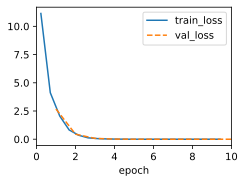

In [9]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=d2l.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

The `fit` call above produces a live plot of the training and validation loss
against the epoch. Both curves fall together and flatten near the irreducible
noise floor (with $\sigma = 0.01$ the per-example squared loss bottoms out around
$\sigma^2/2 \approx 5\times 10^{-5}$). The validation curve tracks the
training curve with **no gap**: a two-dimensional linear model fit on 1000
examples has no capacity to overfit. We return to the train/validation gap, and
what to do when it opens, in that section.

Because we synthesized the dataset ourselves,
we know precisely what the true parameters are.
Thus, we can evaluate our success in training
by comparing the true parameters
with those that we learned through our training loop.
Indeed they turn out to be very close to each other.

In [10]:
print(f"error in estimating w: "
      f"{data.w - d2l.reshape(model.w[...], data.w.shape)}")
print(f"error in estimating b: {data.b - model.b[...]}")

error in estimating w: [ 0.00042462 -0.00062323]
error in estimating b: [0.00096321]


We should not take the ability to exactly recover 
the ground truth parameters for granted.
In general, for deep models unique solutions
for the parameters do not exist,
and even for linear models,
exactly recovering the parameters
is only possible when no feature 
is linearly dependent on the others.
However, in machine learning, 
we are often less concerned
with recovering true underlying parameters,
but rather with parameters 
that lead to highly accurate prediction [@Vapnik.1992].
Fortunately, even on difficult optimization problems,
stochastic gradient descent can often find good solutions,
owing partly to the fact that, for deep networks,
there exist many configurations of the parameters
that lead to highly accurate prediction.
Why the solutions that SGD finds among these many candidates
also *generalize* so well is a deep question,
taken up in that section.


## Summary

In this section, we took a significant step 
towards designing deep learning systems 
by implementing a fully functional 
neural network model and training loop.
In this process, we built a data loader, 
a model, a loss function, an optimization procedure,
and a visualization and monitoring tool. 
We did this by composing a Python object 
that contains all relevant components for training a model. 
While this is not yet a professional-grade implementation
it is perfectly functional and code like this 
could already help you to solve small problems quickly.
In the coming sections, we will see how to do this
both *more concisely* (avoiding boilerplate code)
and *more efficiently* (using our GPUs to their full potential).

The hand-rolled SGD above is the simplest member of a large family: momentum,
AdaGrad, RMSProp, and Adam all replace that single update line, and learning-rate
schedules anneal $\eta$ over the course of training; these are developed in
that section. The squared loss, likewise, is a modelling
choice; in that section we add a penalty on $\|\mathbf{w}\|$ to
curb overfitting, the first of many regularizers we will meet.


## Exercises

1. What would happen if we were to initialize the weights to zero. Would the algorithm still work? What if we
   initialized the parameters with variance $1000$ rather than $0.01$?
1. Assume that you are [Georg Simon Ohm](https://en.wikipedia.org/wiki/Georg_Ohm) trying to come up
   with a model for resistance that relates voltage and current. Can you use automatic
   differentiation to learn the parameters of your model?
1. Can you use [Planck's Law](https://en.wikipedia.org/wiki/Planck%27s_law) to determine the temperature of an object
   using spectral energy density? For reference, the spectral density $B$ of radiation emanating from a black body is
   $B(\lambda, T) = \frac{2 hc^2}{\lambda^5} \cdot \left(\exp \frac{h c}{\lambda k T} - 1\right)^{-1}$. Here
   $\lambda$ is the wavelength, $T$ is the temperature, $c$ is the speed of light, $h$ is Planck's constant, and $k$ is the
   Boltzmann constant. You measure the energy for different wavelengths $\lambda$ and you now need to fit the spectral
   density curve to Planck's law.
1. What are the problems you might encounter if you wanted to compute the second derivatives of the loss? How would
   you fix them?
1. Why is the `reshape` method needed in the `loss` function?
1. Experiment using different learning rates to find out how quickly the loss function value drops. Can you reduce the
   error by increasing the number of epochs of training?
1. Try implementing a different loss function, such as the absolute value loss `(y_hat - d2l.reshape(y, y_hat.shape)).abs().mean()`. (If you *sum* rather than average, the gradient scales with the batch size, so you must lower the learning rate to compensate.)
    1. Check what happens for regular data.
    1. Check whether there is a difference in behavior if you actively perturb some entries, such as $y_5 = 10000$, of $\mathbf{y}$.
    1. Can you think of a cheap solution for combining the best aspects of squared loss and absolute value loss?
       Hint: how can you avoid really large gradient values?
1. Why do we need to reshuffle the dataset? Can you design a case where a maliciously constructed dataset would break the optimization algorithm otherwise?

[Discussions](https://d2l.discourse.group/t/17976)